# Draft

In [ ]:
import lightning.pytorch as pl
import webdataset as wds
import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import io
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.color import rgb2hed, hed2rgb

import glob


In [ ]:
%load_ext autoreload
%autoreload 1
%aimport ...

In [2]:
from src.segmentation.constants import PATH_SEG_DATA

In [ ]:
def custom_decoder(key, data):
    if key.endswith("image.png"):
        return np.array(Image.open(io.BytesIO(data)).convert("RGB"))
    elif key.endswith("mask.png"):
        return np.array(Image.open(io.BytesIO(data)).convert("P"))
    return None

class HEDStainJitter(A.ImageOnlyTransform):
    def __init__(self, strength=0.05, p=0.5):
        super().__init__(p=p)
        self.strength = strength

    def apply(self, img, **params):
        img_float = img.astype(np.float32) / 255.0
        hed        = rgb2hed(img_float)

        for i in range(3):
            hed[:, :, i] += np.random.uniform(-self.strength, self.strength)

        rgb = hed2rgb(hed)
        rgb = np.clip(rgb, 0, 1)
        return (rgb * 255).astype(np.uint8)

    def get_transform_init_args_names(self):
        return ("strength",)


def get_wsi_transforms(mode: str):
    assert mode in ("train", "eval")

    shared = [
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std =(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]

    if mode == "eval":
        return A.Compose(shared)

    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),                 # rotations à 0/90/180/270°
        A.ElasticTransform(                      # déformation du tissu
            alpha=120, sigma=6,
            p=0.2,
        ),

        # ── Couleur / coloration ───────────────────────────────────────────────
        # HEDStainJitter(strength=0.05, p=0.7),   # variation inter-scanner (priorité haute)
        A.ColorJitter(                           # luminosité / contraste globaux
            brightness=0.15,
            contrast=0.15,
            saturation=0.1,
            p=0.5,
        ),
        # ── Artefacts scanner ──────────────────────────────────────────────────
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),   # variation de mise au point
        *shared,
    ])

class SegmentationDataModule(pl.LightningDataModule):
    def __init__(self, train_urls: str | list[str],
                 val_urls: str | list[str],
                 test_urls: str | list[str],
                 batch_size: int = 32, num_workers: int = 4):
        super().__init__()
        self.train_urls = train_urls
        self.test_urls = test_urls
        self.val_urls = val_urls
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_transform = get_wsi_transforms('train')
        self.eval_transform = get_wsi_transforms('eval')

    def _process_sample(self, sample_tuple, is_train=True):
        _, img, mask = sample_tuple
        
        transform = self.train_transform if is_train else self.eval_transform
        augmented = transform(image=img, mask=mask)
        
        img_tensor = augmented['image']
        mask_tensor = augmented['mask'].long() 
        
        return img_tensor, mask_tensor

    def setup(self, stage=None):
        # Webdataset take care of it
        pass

    def train_dataloader(self):
        dataset = (
            # 1. split_by_node prévient Lightning d'essayer de séparer les données
            wds.WebDataset(self.train_urls, nodesplitter=wds.split_by_node, shardshuffle=False)
            .split_by_worker()
            .shuffle(1000)
            .decode(custom_decoder)
            .to_tuple("__key__", "image.png", "mask.png")
            .map(lambda x: self._process_sample(x, is_train=True))
            .with_epoch(10000) # Force l'epoch à s'arrêter après 10 000 batchs
        )

        return DataLoader(
            dataset, 
            batch_size=self.batch_size, 
            num_workers=self.num_workers,
            pin_memory=True
        )

    def val_dataloader(self):
        # Pipeline de validation (Plus simple : pas de shuffle, pas d'augmentation)
        dataset = (
            wds.WebDataset(self.val_urls, nodesplitter=wds.split_by_node, shardshuffle=False)
            .split_by_worker()
            .decode(custom_decoder)
            .to_tuple("__key__", "image.png", "mask.png")
            .map(lambda x: self._process_sample(x, is_train=False))
        )

        return DataLoader(
            dataset, 
            batch_size=self.batch_size, 
            num_workers=self.num_workers,
            pin_memory=True
        )
    
    def test_dataloader(self):
        dataset = (
            wds.WebDataset(self.test_urls, nodesplitter=wds.split_by_node, shardshuffle=False)
            .split_by_worker()
            .decode(custom_decoder)
            .to_tuple("__key__", "image.png", "mask.png")
            .map(lambda x: self._process_sample(x, is_train=False))
        )

        return DataLoader(
            dataset, 
            batch_size=self.batch_size, 
            num_workers=self.num_workers,
            pin_memory=True
        )

In [36]:
def get_path_shards(split: str):
    path_to_shards = str(PATH_SEG_DATA / 'data-shards')
    return glob.glob(path_to_shards + f"/dataset-{split}-*.tar")

data_module = SegmentationDataModule(
    train_urls=get_path_shards('train'),
    val_urls=get_path_shards('val'),
    test_urls=get_path_shards('test'),
    batch_size=4, 
    num_workers=0 
)

=== VÉRIFICATION DES TENSEURS ===
Images batch shape : torch.Size([4, 3, 224, 224]) (Attendu : [Batch, 3, H, W])
Images dtype       : torch.float32 (Attendu : torch.float32)
Valeurs Images     : Min=-2.12, Max=2.64

Masks batch shape  : torch.Size([4, 224, 224]) (Attendu : [Batch, H, W])
Masks dtype        : torch.int64 (Attendu : torch.int64 ou torch.long)
Classes présentes  : [0, 1, 2, 3]


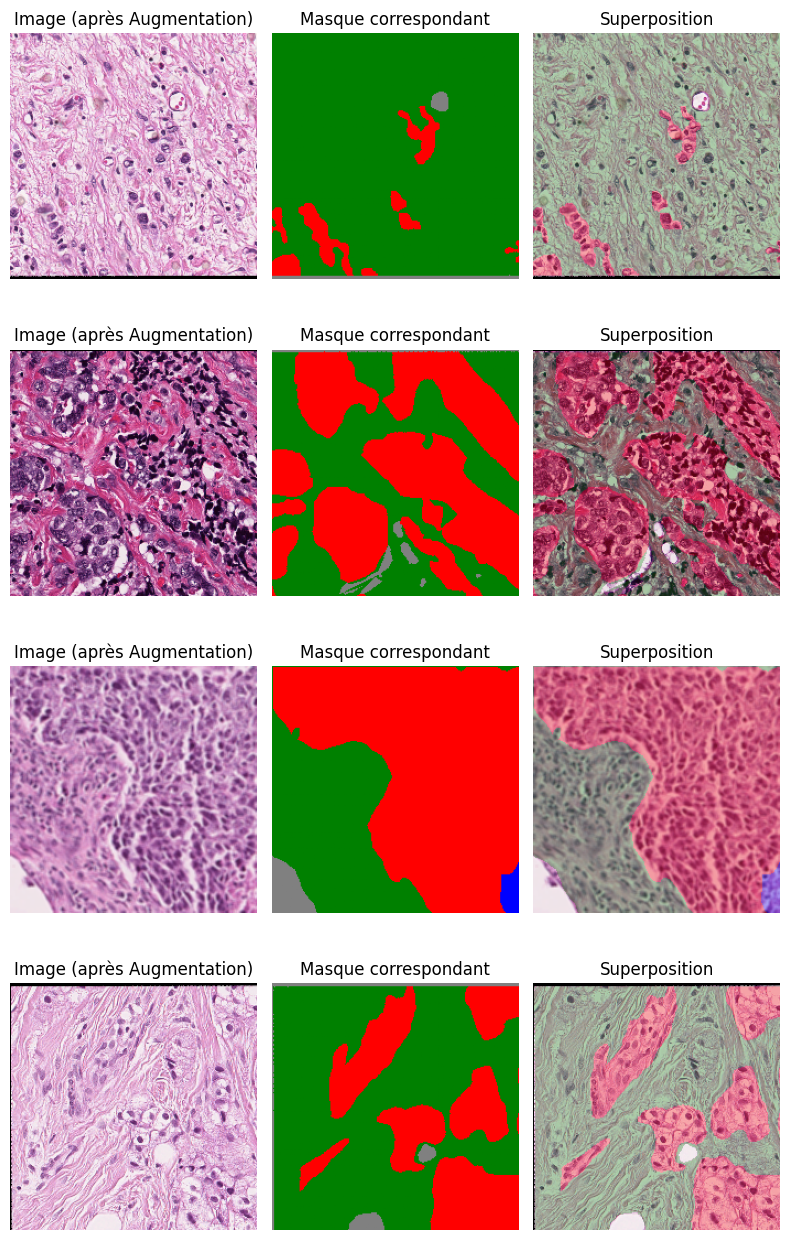

In [39]:
train_loader = data_module.train_dataloader()

# 3. "Tirez" le tout premier batch en utilisant iter() et next()
images, masks = next(iter(train_loader))

class_dict = {
    0: ("other", "gray"),
    1: ("tumeur", "red"),      
    2: ("necrosis", "blue"), 
    3: ("stroma", "green"),
}

# Extraction des couleurs pour créer la Colormap fixe
colors = [class_dict[i][1] for i in sorted(class_dict.keys())]
custom_cmap = ListedColormap(colors)

# Valeurs min et max pour forcer l'alignement des couleurs
vmin = 0
vmax = len(class_dict) - 1

print("=== VÉRIFICATION DES TENSEURS ===")
print(f"Images batch shape : {images.shape} (Attendu : [Batch, 3, H, W])")
print(f"Images dtype       : {images.dtype} (Attendu : torch.float32)")
print(f"Valeurs Images     : Min={images.min():.2f}, Max={images.max():.2f}\n")

print(f"Masks batch shape  : {masks.shape} (Attendu : [Batch, H, W])")
print(f"Masks dtype        : {masks.dtype} (Attendu : torch.int64 ou torch.long)")
print(f"Classes présentes  : {torch.unique(masks).tolist()}")

fig, axes = plt.subplots(len(images), 3, figsize=(8, 3 * len(images) + 1))

for i in range(len(images)):

    # 4. Affichage visuel du premier élément du batch
    # PyTorch utilise le format [Canal, Hauteur, Largeur]. 
    # Matplotlib veut [Hauteur, Largeur, Canal]. On utilise .permute() pour réarranger.
    img_display = images[i].permute(1, 2, 0).numpy()
    mask_display = masks[i].numpy()

    # --- ATTENTION : GESTION DE LA NORMALISATION ---
    # Si vous avez utilisé A.Normalize (ImageNet) dans Albumentations, 
    # l'image aura des couleurs bizarres et des valeurs négatives.
    # Pour l'afficher correctement, on doit "dé-normaliser" visuellement :
    if images.min() < 0:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)


    #plt.subplot(len(images), 3, i+1)
    axes[i, 0].set_title("Image (après Augmentation)")
    axes[i, 0].imshow(img_display)
    axes[i, 0].axis('off')

    #plt.subplot(len(images), 3, i+2)
    axes[i, 1].set_title("Masque correspondant")
    axes[i, 1].imshow(mask_display, cmap=custom_cmap, vmin=vmin, vmax=vmax)
    axes[i, 1].axis('off')

    #plt.subplot(len(images), 3, 3)
    axes[i, 2].set_title("Superposition")
    axes[i, 2].imshow(img_display)
    mask_overlay = np.ma.masked_where(mask_display == 0, mask_display)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    axes[i, 2].axis('off')

plt.tight_layout()